# **Inverse Modeling of Vertical Model**

In [3]:
%env CUDA_VISIBLE_DEVICES = 5
import torch
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
import sys
sys.path.append("../../../..")
from ConditionalDiffusionGeneration.src.guided_diffusion.unet import create_model, create_DiT_model
from ConditionalDiffusionGeneration.src.guided_diffusion.condition_methods import get_conditioning_method
from ConditionalDiffusionGeneration.src.guided_diffusion.measurements import get_noise, get_operator, retrieve_min_max, norm, unnorm
from ConditionalDiffusionGeneration.src.guided_diffusion.gaussian_diffusion import create_sampler
from einops import rearrange

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    dev = "cuda"
else:
    dev = "cpu"

device = torch.device(dev)
print(device)

def plot_ksp(k, sat, pre):
    fig, axs = plt.subplots(1, 3, figsize=(7, 2))
    im0 = axs[0].imshow(k, cmap='jet', origin='lower')
    axs[0].set_title('Permeability')
    plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    
    im1 = axs[1].imshow(sat[3], cmap='jet', vmin=0, vmax=1, origin='lower')
    axs[1].set_title('Saturation')
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
    
    im2 = axs[2].imshow(pre[-1], cmap='jet', origin='lower')
    axs[2].set_title('Pressure')
    plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)
    axs[0].axis('off')
    axs[1].axis('off')
    axs[2].axis('off')
    plt.show()

env: CUDA_VISIBLE_DEVICES=5
cuda


In [2]:
u_net_model = create_DiT_model(
                            input_size=64,
                            patch_size=2,
                            in_channels=1,
                            hidden_size=256,
                            depth=12,
                            num_heads=8,
                            mlp_ratio=4.0,
                            class_dropout_prob=0.0,
                            num_classes=None,
                            learn_sigma=True,
                            model_path='/ehome/zhao/DiffNO/UnconditionalDiffusionTraining_and_Generation/output/logs_gaussian_vertical_dit/ema_0.9999_350000.pt'
                        )

u_net_model.to(device)
u_net_model.eval()
print('loaded unet (actually DiT) model')

loaded unet (actually DiT) model


>>>>> Loading test data from /ehome/zhao/DiffNO/dataset/Multi_Cartesian_Gaussian_vertical.hdf5
Test data loaded, with shape K: (64, 64), Sg: (10, 64, 64), P: (10, 64, 64)


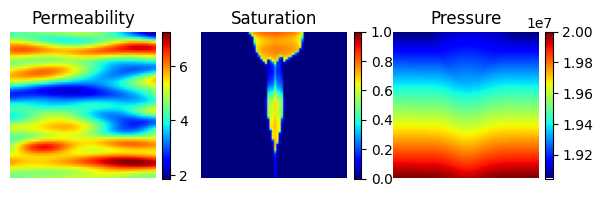

In [4]:
with_perm = False

operator =  get_operator(name='vertical_sparse_well_5',
                        device=device,
                        hdf5_path='/ehome/zhao/DiffNO/dataset/Multi_Cartesian_Gaussian_vertical.hdf5',
                        test_idx=60,    # 60
                        end_t_idx=4,  # 4 time steps during injection period for history matching   
                        with_perm=with_perm,
                        )
plot_ksp(operator.perm, operator.sat, operator.pre)

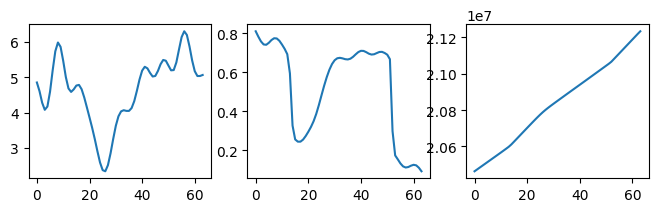

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(8, 2))
axs[0].plot(operator.perm[:, 32][::-1], label='permeability')
axs[1].plot(operator.sat[3, :, 32][::-1], label='saturation')
axs[2].plot(operator.pre[3, :, 32][::-1], label='pressure')
plt.show()

In [4]:
noiser = get_noise(sigma=0.0, name='gaussian')
cond_method = get_conditioning_method(operator=operator, noiser=noiser, name='ps_adam', scale=1e-2)
measurement_cond_fn = partial(cond_method.conditioning)

### Sampler

In [5]:
sampler = create_sampler(sampler='ddpm',
                        steps=1000,
                        noise_schedule="cosine",
                        model_mean_type="epsilon",
                        model_var_type="learned_range",
                        dynamic_threshold=False,
                        clip_denoised=True,
                        rescale_timesteps=False,
                        timestep_respacing="")

sample_fn = partial(sampler.p_sample_loop, model=u_net_model, measurement_cond_fn=measurement_cond_fn)

In [6]:
no_of_samples = 20
image_size = 64

x_start = torch.randn(no_of_samples, 1, image_size, image_size, device=device)
measurement_ref = operator.measurement()
samples = [sample_fn(x_start=x_start[i:i+1], measurement=measurement_ref, record=False, save_root=None) for i in range(x_start.shape[0])]

Measurement shape: torch.Size([1, 2, 4, 320])


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [7]:
gen = torch.cat(samples)
gen = unnorm(gen, retrieve_min_max('perm_vertical')[0], retrieve_min_max('perm_vertical')[1])
gen = gen[:, 0]
print(f"Generated images shape: {gen.shape}") 
torch.save(gen, f'conditional_outputs/pts/vertical_5wells_injection.pt')

Generated images shape: torch.Size([20, 64, 64])


### ***Load pt records (CNF out & reference)***

In [5]:
def retrieve_all(file_name):
    gene = torch.load(f'conditional_outputs/pts/{file_name}.pt', map_location='cpu').detach().numpy()
    print(f"Retrieved generated perms shape: {gene.shape}")
    return gene
ref = operator.retrieve_reference()
ref_k = ref['perm']
ref_pre = ref['pre']
ref_sat = ref['sat']
print(f"Reference K shape: {ref_k.shape}, Reference P/Sg shape: {ref_pre.shape}/{ref_sat.shape}")

gene_3well_injection = retrieve_all('vertical_3wells_injection')
gene_3well_injection_with_perm = retrieve_all('vertical_3wells_injection_with_perm')
gene_3well_injection_noise = retrieve_all('vertical_3wells_injection_noise')
gene_5well_injection = retrieve_all('vertical_5wells_injection')
gene_5well_injection_with_perm = retrieve_all('vertical_5wells_injection_with_perm')

Retrieving reference:
perm: shape (64, 64)
sat: shape (10, 64, 64)
pre: shape (10, 64, 64)
Reference K shape: (64, 64), Reference P/Sg shape: (10, 64, 64)/(10, 64, 64)
Retrieved generated perms shape: (20, 64, 64)
Retrieved generated perms shape: (20, 64, 64)
Retrieved generated perms shape: (20, 64, 64)
Retrieved generated perms shape: (20, 64, 64)
Retrieved generated perms shape: (20, 64, 64)


In [6]:
from Surrogate.ufno import Net3d

def ufno_pred(k):
    if not isinstance(k, torch.Tensor):
        k = torch.tensor(k, dtype=torch.float32).to(device)
    k = norm(k, retrieve_min_max('perm_vertical')[0], retrieve_min_max('perm_vertical')[1]).unsqueeze(1)
    print(f'input k shape: {k.shape}')
    
    tn = [1*12, 2*12, 3*12, 4*12, 5*12, 6*12, 7*12, 8*12, 9*12, 10*12]  # 10 time steps in months
    ts = [t*86400*30 for t in tn]
    normed_ts = norm(np.array(ts), retrieve_min_max('ts_vertical')[0], retrieve_min_max('ts_vertical')[1])
    normed_ts = np.tile(normed_ts[:, None, None], (1, 64, 64))    # <1, 64, 64>
    normed_ts = torch.tensor(normed_ts, dtype=torch.float32).to(device)
    
    batch_size = k.shape[0]
    ts_expand = normed_ts.expand(batch_size, -1, -1, -1)
    k_expand = k.expand(-1, ts_expand.size(1), -1, -1)
    assert ts_expand.shape == k_expand.shape, f"UFNO input shapes mismatch: {ts_expand.shape}, {k_expand.shape}"
    
    x_surrogate = torch.stack((k_expand, ts_expand), dim=-1)    # <b, t, 64, 64, c=2>
    x_surrogate = rearrange(x_surrogate, 'b t h w c -> b h w t c')
    print(f'UFNO input shape: {x_surrogate.shape}')
    
    sg_ufno = Net3d(modes1=10, modes2=10, modes3=8, width=36).to(device)
    p_ufno = Net3d(modes1=10, modes2=10, modes3=8, width=36).to(device)
    sg_ufno.load_state_dict(torch.load('/ehome/zhao/DiffNO/checkpoint/ufno_sat_vertical.pth')['model_state_dict'])
    p_ufno.load_state_dict(torch.load('/ehome/zhao/DiffNO/checkpoint/ufno_pre_vertical.pth')['model_state_dict'])
    sg_ufno.eval()
    p_ufno.eval()
    
    pred_sg = sg_ufno(x_surrogate)
    pred_p = p_ufno(x_surrogate)
    
    if len(pred_sg.shape) < 4:
        pred_sg = pred_sg.unsqueeze(0)
    if len(pred_p.shape) < 4:
        pred_p = pred_p.unsqueeze(0)
    
    pred_sg = rearrange(pred_sg, 'b h w t -> b t h w')
    pred_p = rearrange(pred_p, 'b h w t -> b t h w')
    
    pred_sg = unnorm(pred_sg, retrieve_min_max('sat_vertical')[0], retrieve_min_max('sat_vertical')[1])
    pred_p = unnorm(pred_p, retrieve_min_max('pre_vertical')[0], retrieve_min_max('pre_vertical')[1])
    
    print(f'UFNO output shapes: sg {pred_sg.shape}, p {pred_p.shape}')
    return pred_sg.detach().cpu().numpy(), pred_p.detach().cpu().numpy()

ufno_sat_SAT, ufno_pre_SAT = ufno_pred(gene_3well_injection)
ufno_sat_SAT_with_perm, ufno_pre_SAT_with_perm = ufno_pred(gene_3well_injection_with_perm)
ufno_sat_SAT_noise, ufno_pre_SAT_noise = ufno_pred(gene_3well_injection_noise)
ufno_sat_5WELL, ufno_pre_5WELL = ufno_pred(gene_5well_injection)
ufno_sat_5WELL_with_perm, ufno_pre_5WELL_with_perm = ufno_pred(gene_5well_injection_with_perm)

input k shape: torch.Size([20, 1, 64, 64])
UFNO input shape: torch.Size([20, 64, 64, 10, 2])
UFNO output shapes: sg torch.Size([20, 10, 64, 64]), p torch.Size([20, 10, 64, 64])
input k shape: torch.Size([20, 1, 64, 64])
UFNO input shape: torch.Size([20, 64, 64, 10, 2])
UFNO output shapes: sg torch.Size([20, 10, 64, 64]), p torch.Size([20, 10, 64, 64])
input k shape: torch.Size([20, 1, 64, 64])
UFNO input shape: torch.Size([20, 64, 64, 10, 2])
UFNO output shapes: sg torch.Size([20, 10, 64, 64]), p torch.Size([20, 10, 64, 64])
input k shape: torch.Size([20, 1, 64, 64])
UFNO input shape: torch.Size([20, 64, 64, 10, 2])
UFNO output shapes: sg torch.Size([20, 10, 64, 64]), p torch.Size([20, 10, 64, 64])
input k shape: torch.Size([20, 1, 64, 64])
UFNO input shape: torch.Size([20, 64, 64, 10, 2])
UFNO output shapes: sg torch.Size([20, 10, 64, 64]), p torch.Size([20, 10, 64, 64])


### Contour visualization

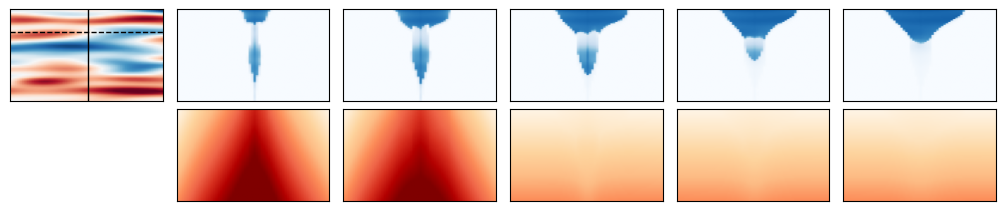

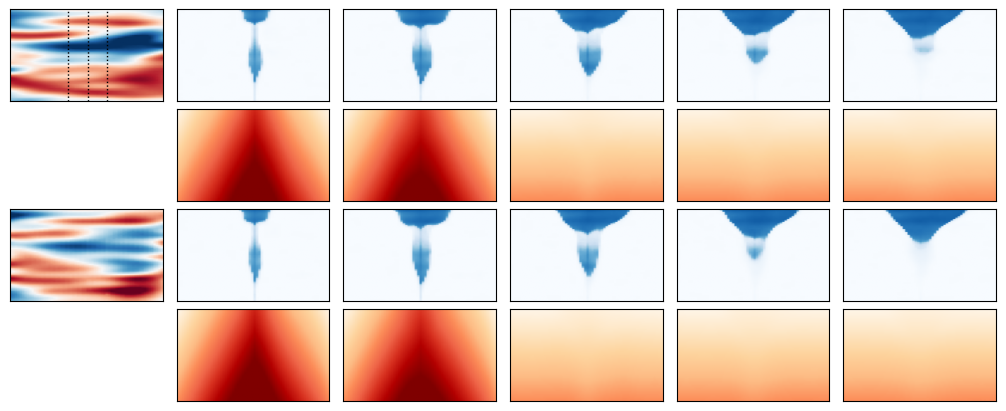

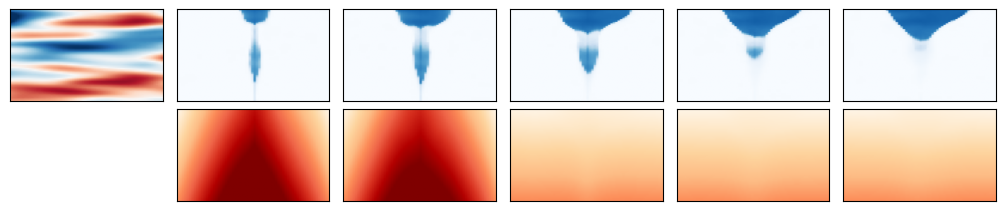

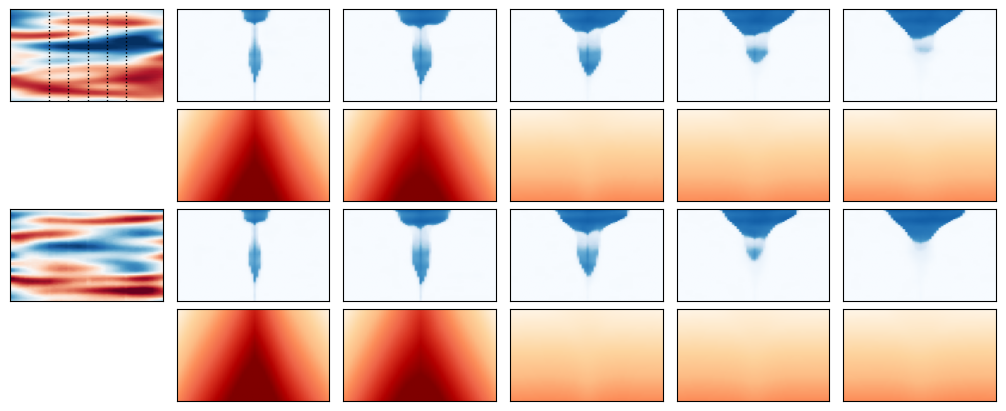

In [64]:
def plot_post_utility(row, col, ax):
    for i in range(row):
        for j in range(col):
            ax[i, j].set_xticks([])
            ax[i, j].set_yticks([])
            ax[i, j].set_aspect(0.6)



def plot_sp_reference(true_k, true_sat, true_pre):
    fig, axs = plt.subplots(2, 6, figsize=(10, 2), constrained_layout=True)
    perm_vmin, perm_vmax = 2, 7
    
    axs[0, 0].imshow(true_k, cmap='RdBu_r', vmin=perm_vmin, vmax=perm_vmax, origin='lower')
    axs[0, 0].axvline(x=32, color='black', linewidth=1, ls='-')
    axs[0, 0].axhline(y=48, color='black', linewidth=1, ls='--')
    
    axs[1, 0].set_visible(False)
    selected_ts = [1, 3, 5, 7, 9]
    for i in range(1, 6):
        axs[0, i].imshow(true_sat[selected_ts[i-1]], cmap='Blues', vmin=0, vmax=1, origin='lower')
        axs[1, i].imshow(true_pre[selected_ts[i-1]], cmap='OrRd', origin='lower', vmin=19e6, vmax=21e6)
    
    plot_post_utility(2, 6, axs)
    return fig
    


# def plot_sp_condition_3well(true_k, true_sat, true_pre):
#     fig, axs = plt.subplots(1, 3, figsize=(6, 3), constrained_layout=True)
#     perm_vmin, perm_vmax = 2, 7
#     well_cols = [24, 32, 40]
    
#     masked_perm = np.full_like(true_k, np.nan)
#     masked_perm[:, well_cols] = true_k[:, well_cols]
    
#     masked_sat = np.full_like(true_sat[3], np.nan)
#     masked_sat[:, well_cols] = true_sat[3][:, well_cols]
    
#     masked_pre = np.full_like(true_pre[3], np.nan)
#     masked_pre[:, well_cols] = true_pre[3][:, well_cols]
    
#     axs[0].imshow(masked_sat, cmap='Blues', vmin=0, vmax=1, origin='lower')
#     axs[1].imshow(masked_pre, cmap='OrRd', origin='lower', vmin=19e6, vmax=21e6)
#     axs[2].imshow(masked_perm, cmap='RdBu_r', vmin=perm_vmin, vmax=perm_vmax, origin='lower')
    
#     for i in range(3):
#         axs[i].set_xticks([])
#         axs[i].set_yticks([])
#         axs[i].set_aspect(0.6)
#     return fig


# def plot_sp_condition_5well(true_k, true_sat, true_pre):
#     fig, axs = plt.subplots(1, 3, figsize=(6, 3), constrained_layout=True)
#     perm_vmin, perm_vmax = 2, 7
#     well_cols = [16, 24, 32, 40, 48]
    
#     masked_perm = np.full_like(true_k, np.nan)
#     masked_perm[:, well_cols] = true_k[:, well_cols]
    
#     masked_sat = np.full_like(true_sat[3], np.nan)
#     masked_sat[:, well_cols] = true_sat[3][:, well_cols]
    
#     masked_pre = np.full_like(true_pre[3], np.nan)
#     masked_pre[:, well_cols] = true_pre[3][:, well_cols]
    
#     axs[0].imshow(masked_sat, cmap='Blues', vmin=0, vmax=1, origin='lower')
#     axs[1].imshow(masked_pre, cmap='OrRd', origin='lower', vmin=19e6, vmax=21e6)
#     axs[2].imshow(masked_perm, cmap='RdBu_r', vmin=perm_vmin, vmax=perm_vmax, origin='lower')
    
#     for i in range(3):
#         axs[i].set_xticks([])
#         axs[i].set_yticks([])
#         axs[i].set_aspect(0.6)
#     return fig
    
    

def plot_sp_results(gene_k, gene_sat, gene_pre, gene_k2, gene_sat2, gene_pre2, well_no):
    fig, axs = plt.subplots(4, 6, figsize=(10, 4), constrained_layout=True)
    perm_vmin, perm_vmax = 2, 7
    
    axs[0, 0].imshow(gene_k[0], cmap='RdBu_r', vmin=perm_vmin, vmax=perm_vmax, origin='lower')
    if well_no == 3:
        well_cols = [24, 32, 40]
        for i in well_cols:
            axs[0, 0].axvline(x=i, color='black', linewidth=1, ls=':')
    elif well_no == 5:
        well_cols = [16, 24, 32, 40, 48]
        for i in well_cols:
            axs[0, 0].axvline(x=i, color='black', linewidth=1, ls=':')
    else:
        raise ValueError("well_no must be either 3 or 5")
    
    axs[1, 0].set_visible(False)
    axs[2, 0].imshow(gene_k2[0], cmap='RdBu_r', vmin=perm_vmin, vmax=perm_vmax, origin='lower')
    axs[3, 0].set_visible(False)
    
    selected_ts = [1, 3, 5, 7, 9]
    for i in range(1, 6):
        axs[0, i].imshow(gene_sat[0][selected_ts[i-1]], cmap='Blues', vmin=0, vmax=1, origin='lower')
        axs[1, i].imshow(gene_pre[0][selected_ts[i-1]], cmap='OrRd', origin='lower', vmin=19e6, vmax=21e6)
        
        axs[2, i].imshow(gene_sat2[0][selected_ts[i-1]], cmap='Blues', vmin=0, vmax=1, origin='lower')
        axs[3, i].imshow(gene_pre2[0][selected_ts[i-1]], cmap='OrRd', origin='lower', vmin=19e6, vmax=21e6)
    
    plot_post_utility(4, 6, axs)
    
    return fig


def plot_sp_single_results(gene_k, gene_sat, gene_pre):
    fig, axs = plt.subplots(2, 6, figsize=(10, 2), constrained_layout=True)
    perm_vmin, perm_vmax = 2, 7
    
    axs[0, 0].imshow(gene_k[0], cmap='RdBu_r', vmin=perm_vmin, vmax=perm_vmax, origin='lower')
    axs[1, 0].set_visible(False)
    
    selected_ts = [1, 3, 5, 7, 9]
    for i in range(1, 6):
        axs[0, i].imshow(gene_sat[0][selected_ts[i-1]], cmap='Blues', vmin=0, vmax=1, origin='lower')
        axs[1, i].imshow(gene_pre[0][selected_ts[i-1]], cmap='OrRd', origin='lower', vmin=19e6, vmax=21e6)
    
    plot_post_utility(2, 6, axs)
    
    return fig

ref_plot = plot_sp_reference(ref_k, ref_sat, ref_pre)
plt.savefig("conditional_outputs/figs_vertical_sp/ref_plot.pdf", bbox_inches='tight')


gene_plot = plot_sp_results(gene_3well_injection, ufno_sat_SAT, ufno_pre_SAT, 
                     gene_3well_injection_with_perm, ufno_sat_SAT_with_perm, ufno_pre_SAT_with_perm, well_no=3)
plt.savefig("conditional_outputs/figs_vertical_sp/gene_plot_3well.pdf", bbox_inches='tight')

gene_plot_noise = plot_sp_single_results(gene_3well_injection_noise, ufno_sat_SAT_noise, ufno_pre_SAT_noise)
plt.savefig("conditional_outputs/figs_vertical_sp/gene_plot_3well_noise.pdf", bbox_inches='tight')


gene_plot_5well = plot_sp_results(gene_5well_injection, ufno_sat_5WELL, ufno_pre_5WELL,
                     gene_5well_injection_with_perm, ufno_sat_5WELL_with_perm, ufno_pre_5WELL_with_perm, well_no=5)
plt.savefig("conditional_outputs/figs_vertical_sp/gene_plot_5well.pdf", bbox_inches='tight')
    

### Point estimates (UQ)

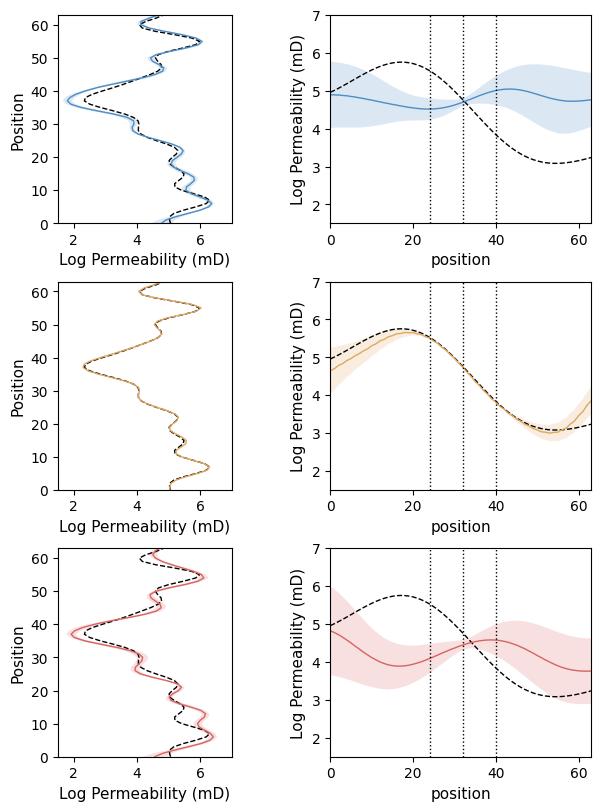

In [61]:
def plot_mean_std(ax, x, array, color, label, ls, lw, vertical=False):
    mean = np.mean(array, axis=0)
    std = np.std(array, axis=0)
    if vertical:
        ax.plot(mean, x, color=color, label=label, linestyle=ls, linewidth=lw)
        ax.fill_betweenx(x, mean - std, mean + std, color=color, alpha=0.2, edgecolor=None)
    else:
        ax.plot(x, mean, color=color, label=label, linestyle=ls, linewidth=lw)
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2, edgecolor=None)


def plot_vertical_and_horizontal_K_line(true_k, gene_k1, gene_k2, gene_k3):
    
    h_idx = 48
    vertical_true_k_line = true_k[:, 32]
    horizontal_true_k_line = true_k[h_idx, :]  # array of shape (64,)
    
    vertical_gene_k1_line = gene_k1[:, :, 32]   # arrray of shape (20, 64)
    vertical_gene_k2_line = gene_k2[:, :, 32]
    vertical_gene_k3_line = gene_k3[:, :, 32]
    
    horizontal_gene_k1_line = gene_k1[:, h_idx, :]   # arrray of shape (20, 64)
    horizontal_gene_k2_line = gene_k2[:, h_idx, :]
    horizontal_gene_k3_line = gene_k3[:, h_idx, :]
    
    x = np.arange(64)
    
    fig, axs = plt.subplots(3, 2, figsize=(6, 8), constrained_layout=True)
    
    # -- baseline --
    axs[0, 0].plot(vertical_true_k_line, x, label='Reference', color='black', linewidth=1, ls='--')
    plot_mean_std(axs[0, 0], x, vertical_gene_k1_line, color='#4e8dc3', label='3 wells', ls='-', lw=1, vertical=True)
    
    axs[0, 1].plot(x, horizontal_true_k_line, label='Reference', color='black', linewidth=1, ls='--')
    plot_mean_std(axs[0, 1], x, horizontal_gene_k1_line, color='#4e8dc3', label='3 wells', ls='-', lw=1)
    axs[0, 1].axvline(x=32, color='black', linewidth=1, ls=':')
    axs[0, 1].axvline(x=40, color='black', linewidth=1, ls=':')
    axs[0, 1].axvline(x=24, color='black', linewidth=1, ls=':')
    
    # -- with perm --
    axs[1, 0].plot(vertical_true_k_line, x, label='Reference', color='black', linewidth=1, ls='--')
    plot_mean_std(axs[1, 0], x, vertical_gene_k2_line, color='#dfa762', label='3 wells + perm', ls='-', lw=1, vertical=True)
    
    axs[1, 1].plot(x, horizontal_true_k_line, label='Reference', color='black', linewidth=1, ls='--')
    plot_mean_std(axs[1, 1], x, horizontal_gene_k2_line, color='#dfa762', label='3 wells + perm', ls='-', lw=1)
    axs[1, 1].axvline(x=32, color='black', linewidth=1, ls=':')
    axs[1, 1].axvline(x=40, color='black', linewidth=1, ls=':')
    axs[1, 1].axvline(x=24, color='black', linewidth=1, ls=':')
    
    
    
    # -- with noise --
    axs[2, 0].plot(vertical_true_k_line, x, label='Reference', color='black', linewidth=1, ls='--')
    plot_mean_std(axs[2, 0], x, vertical_gene_k3_line, color='#d76462', label='5 wells + perm', ls='-', lw=1, vertical=True)
    
    axs[2, 1].plot(x, horizontal_true_k_line, label='Reference', color='black', linewidth=1, ls='--')
    plot_mean_std(axs[2, 1], x, horizontal_gene_k3_line, color='#d76462', label='5 wells + perm', ls='-', lw=1)
    axs[2, 1].axvline(x=32, color='black', linewidth=1, ls=':')
    axs[2, 1].axvline(x=40, color='black', linewidth=1, ls=':')
    axs[2, 1].axvline(x=24, color='black', linewidth=1, ls=':')
    
    for i in range(3):
        axs[i, 0].set_ylabel('Position', fontsize=11)
        axs[i, 0].set_xlabel('Log Permeability (mD)', fontsize=11)
        axs[i, 0].set_xlim(1.5, 7)
        axs[i, 0].set_ylim(0, 63)
        axs[i, 0].set_box_aspect(1.2)
        
        axs[i, 1].set_xlabel('position', fontsize=11)
        axs[i, 1].set_ylabel('Log Permeability (mD)', fontsize=11)
        axs[i, 1].set_ylim(1.5, 7)
        axs[i, 1].set_xlim(0, 63)
        axs[i, 1].set_box_aspect(0.8)
        
    

    return fig

k_line_3well = plot_vertical_and_horizontal_K_line(ref_k, gene_3well_injection, gene_3well_injection_with_perm, gene_3well_injection_noise)
plt.savefig("conditional_outputs/figs_vertical_sp/k_line_3well.pdf", bbox_inches='tight')

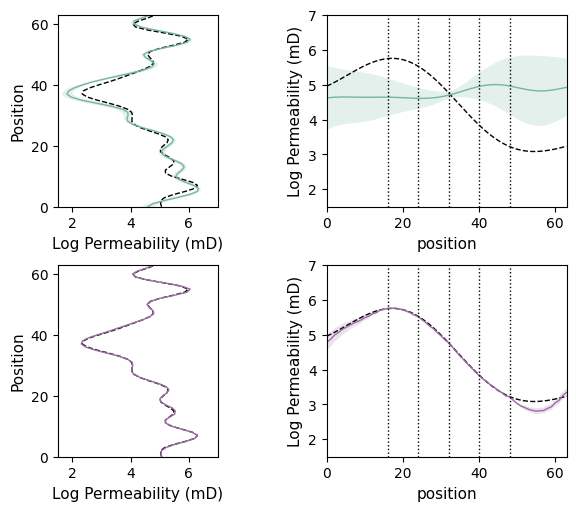

In [62]:
def plot_vertical_and_horizontal_K_line_5well(true_k, gene_k1, gene_k2):
    
    h_idx = 48
    vertical_true_k_line = true_k[:, 32]
    horizontal_true_k_line = true_k[h_idx, :]  # array of shape (64,)
    
    vertical_gene_k1_line = gene_k1[:, :, 32]   # arrray of shape (20, 64)
    vertical_gene_k2_line = gene_k2[:, :, 32]
    
    horizontal_gene_k1_line = gene_k1[:, h_idx, :]   # arrray of shape (20, 64)
    horizontal_gene_k2_line = gene_k2[:, h_idx, :]
    
    x = np.arange(64)
    
    fig, axs = plt.subplots(2, 2, figsize=(6, 5), constrained_layout=True)
    
    # -- baseline --
    axs[0, 0].plot(vertical_true_k_line, x, label='Reference', color='black', linewidth=1, ls='--')
    plot_mean_std(axs[0, 0], x, vertical_gene_k1_line, color="#76b5a1", label='3 wells', ls='-', lw=1, vertical=True)
    
    axs[0, 1].plot(x, horizontal_true_k_line, label='Reference', color='black', linewidth=1, ls='--')
    plot_mean_std(axs[0, 1], x, horizontal_gene_k1_line, color='#76b5a1', label='3 wells', ls='-', lw=1)
    axs[0, 1].axvline(x=32, color='black', linewidth=1, ls=':')
    axs[0, 1].axvline(x=40, color='black', linewidth=1, ls=':')
    axs[0, 1].axvline(x=24, color='black', linewidth=1, ls=':')
    axs[0, 1].axvline(x=16, color='black', linewidth=1, ls=':')
    axs[0, 1].axvline(x=48, color='black', linewidth=1, ls=':')
    
    # -- with perm --
    axs[1, 0].plot(vertical_true_k_line, x, label='Reference', color='black', linewidth=1, ls='--')
    plot_mean_std(axs[1, 0], x, vertical_gene_k2_line, color="#9d6ea4", label='3 wells + perm', ls='-', lw=1, vertical=True)
    
    axs[1, 1].plot(x, horizontal_true_k_line, label='Reference', color='black', linewidth=1, ls='--')
    plot_mean_std(axs[1, 1], x, horizontal_gene_k2_line, color='#9d6ea4', label='3 wells + perm', ls='-', lw=1)
    axs[1, 1].axvline(x=32, color='black', linewidth=1, ls=':')
    axs[1, 1].axvline(x=40, color='black', linewidth=1, ls=':')
    axs[1, 1].axvline(x=24, color='black', linewidth=1, ls=':')
    axs[1, 1].axvline(x=16, color='black', linewidth=1, ls=':')
    axs[1, 1].axvline(x=48, color='black', linewidth=1, ls=':')
    
    for i in range(2):
        axs[i, 0].set_ylabel('Position', fontsize=11)
        axs[i, 0].set_xlabel('Log Permeability (mD)', fontsize=11)
        axs[i, 0].set_xlim(1.5, 7)
        axs[i, 0].set_ylim(0, 63)
        axs[i, 0].set_box_aspect(1.2)
        
        
        axs[i, 1].set_xlabel('position', fontsize=11)
        axs[i, 1].set_ylabel('Log Permeability (mD)', fontsize=11)
        axs[i, 1].set_ylim(1.5, 7)
        axs[i, 1].set_xlim(0, 63)
        axs[i, 1].set_box_aspect(0.8)
        
    

    return fig

k_line_3well = plot_vertical_and_horizontal_K_line_5well(ref_k, gene_5well_injection, gene_5well_injection_with_perm)
plt.savefig("conditional_outputs/figs_vertical_sp/k_line_5well.pdf", bbox_inches='tight')

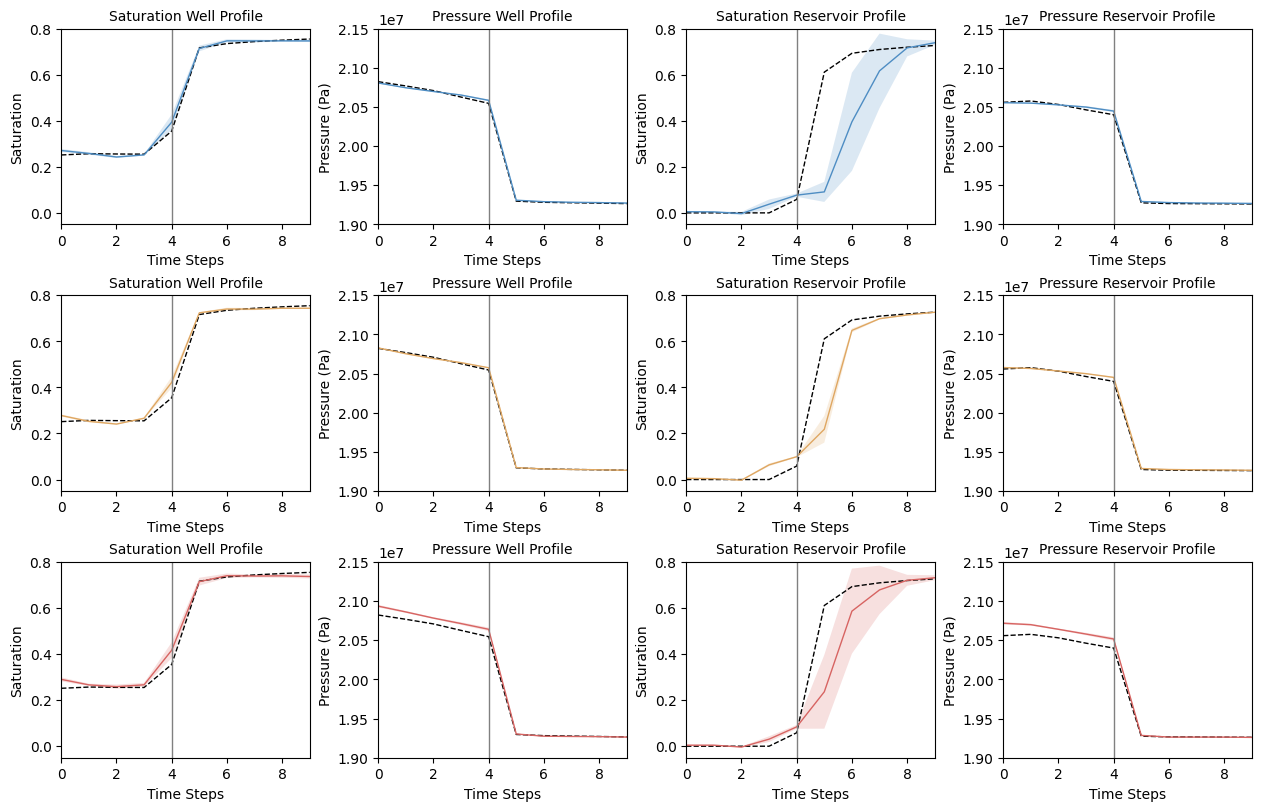

In [69]:
def retrieve_ps(pressure, saturation, pt=[48,32], res_pt=[48,36], ref=False):
    if ref == False:
        pressure_line = pressure[:, :, pt[0], pt[1]]
        saturation_line = saturation[:, :, pt[0], pt[1]]    # shape (20, 10)
        pressure_line_res = pressure[:, :, res_pt[0], res_pt[1]]
        saturation_line_res = saturation[:, :, res_pt[0], res_pt[1]]
    else:
        pressure_line = pressure[:, pt[0], pt[1]]
        saturation_line = saturation[:, pt[0], pt[1]]
        pressure_line_res = pressure[:, res_pt[0], res_pt[1]]
        saturation_line_res = saturation[:, res_pt[0], res_pt[1]]
    return pressure_line, saturation_line, pressure_line_res, saturation_line_res

def plot_mean_std_v2(ax, x, array, color, ls='-', lw=1):
    mean = np.mean(array, axis=0)
    std = np.std(array, axis=0)
    ax.plot(x, mean, color=color, linestyle=ls, linewidth=lw)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2, edgecolor=None)

def plot_temporal_ps_3well(true_sat, true_pre, gene_sat1, gene_pre1, gene_sat2, gene_pre2, gene_sat3, gene_pre3):
    true_pre_line, true_sat_line, true_pre_line_res, true_sat_line_res = retrieve_ps(true_pre, true_sat, ref=True)
    gene1_pre_line, gene1_sat_line, gene1_pre_line_res, gene1_sat_line_res = retrieve_ps(gene_pre1, gene_sat1)
    gene2_pre_line, gene2_sat_line, gene2_pre_line_res, gene2_sat_line_res = retrieve_ps(gene_pre2, gene_sat2)
    gene3_pre_line, gene3_sat_line, gene3_pre_line_res, gene3_sat_line_res = retrieve_ps(gene_pre3, gene_sat3)
    
    gene_pre_lines = [gene1_pre_line, gene2_pre_line, gene3_pre_line]
    gene_sat_lines = [gene1_sat_line, gene2_sat_line, gene3_sat_line]
    gene_pre_lines_res = [gene1_pre_line_res, gene2_pre_line_res, gene3_pre_line_res]
    gene_sat_lines_res = [gene1_sat_line_res, gene2_sat_line_res, gene3_sat_line_res]

    colors_3 = ['#4e8dc3', '#dfa762', '#d76462']
    x_pos = np.arange(10)
    x_end_idx = 4
    axis_fontsize = 10
    
    fig, axs = plt.subplots(3, 4, figsize=(12.5, 8), constrained_layout=True)
    for i in range(3):
        axs[i, 0].plot(x_pos, true_sat_line, color='black', linewidth=1, ls='--')
        plot_mean_std_v2(axs[i, 0], x_pos, gene_sat_lines[i], color=colors_3[i])
        axs[i, 0].set_title('Saturation Well Profile', fontsize=axis_fontsize)
        axs[i, 0].set_ylabel('Saturation', fontsize=axis_fontsize)
        
        axs[i, 1].plot(x_pos, true_pre_line, color='black', linewidth=1, ls='--')
        plot_mean_std_v2(axs[i, 1], x_pos, gene_pre_lines[i], color=colors_3[i])
        axs[i, 1].set_title('Pressure Well Profile', fontsize=axis_fontsize)
        axs[i, 1].set_ylabel('Pressure (Pa)', fontsize=axis_fontsize)
        
        axs[i, 2].plot(x_pos, true_sat_line_res, color='black', linewidth=1, ls='--')
        plot_mean_std_v2(axs[i, 2], x_pos, gene_sat_lines_res[i], color=colors_3[i])
        axs[i, 2].set_title('Saturation Reservoir Profile', fontsize=axis_fontsize)
        axs[i, 2].set_ylabel('Saturation', fontsize=axis_fontsize)
        
        axs[i, 3].plot(x_pos, true_pre_line_res, color='black', linewidth=1, ls='--')
        plot_mean_std_v2(axs[i, 3], x_pos, gene_pre_lines_res[i], color=colors_3[i])
        axs[i, 3].set_title('Pressure Reservoir Profile', fontsize=axis_fontsize)
        axs[i, 3].set_ylabel('Pressure (Pa)', fontsize=axis_fontsize)
    
    
    for i in range(3):
        for j in range(4):
            axs[i, j].set_xlabel('Time Steps', fontsize=axis_fontsize)
            axs[i, j].axvline(x=x_end_idx, color='gray', linewidth=1, ls='-')
            axs[i, j].set_xlim(0, 9)

            if j % 2 == 0:
                axs[i, j].set_ylim(-0.05, 0.8)
            else:
                axs[i, j].set_ylim(19e6, 21.5e6)
    
    return fig

ff = plot_temporal_ps_3well(ref_sat, ref_pre, 
                        ufno_sat_SAT, ufno_pre_SAT, 
                        ufno_sat_SAT_with_perm, ufno_pre_SAT_with_perm, 
                        ufno_sat_SAT_noise, ufno_pre_SAT_noise)

plt.savefig("conditional_outputs/figs_vertical_sp/sp_line_3well.pdf", bbox_inches='tight')

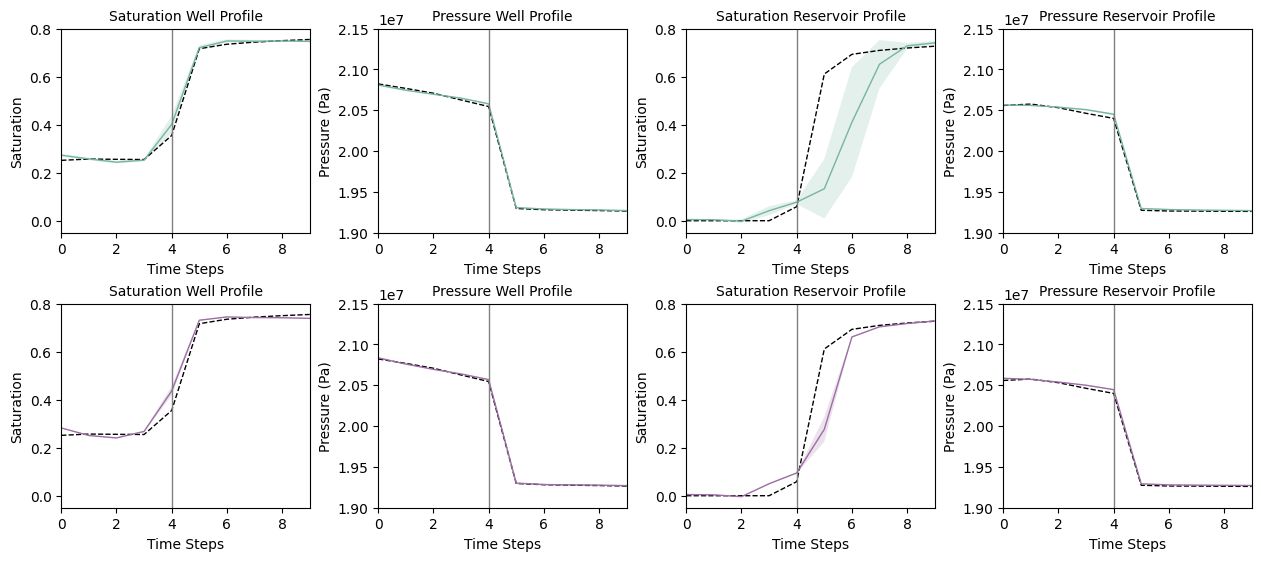

In [74]:
def plot_temporal_ps_5well(true_sat, true_pre, gene_sat1, gene_pre1, gene_sat2, gene_pre2):
    true_pre_line, true_sat_line, true_pre_line_res, true_sat_line_res = retrieve_ps(true_pre, true_sat, ref=True)
    gene1_pre_line, gene1_sat_line, gene1_pre_line_res, gene1_sat_line_res = retrieve_ps(gene_pre1, gene_sat1)
    gene2_pre_line, gene2_sat_line, gene2_pre_line_res, gene2_sat_line_res = retrieve_ps(gene_pre2, gene_sat2)
    
    gene_pre_lines = [gene1_pre_line, gene2_pre_line,]
    gene_sat_lines = [gene1_sat_line, gene2_sat_line,]
    gene_pre_lines_res = [gene1_pre_line_res, gene2_pre_line_res,]
    gene_sat_lines_res = [gene1_sat_line_res, gene2_sat_line_res,]

    colors_3 = ['#76b5a1', '#9d6ea4',]
    x_pos = np.arange(10)
    x_end_idx = 4
    axis_fontsize = 10
    
    fig, axs = plt.subplots(2, 4, figsize=(12.5, 5.5), constrained_layout=True)
    for i in range(2):
        axs[i, 0].plot(x_pos, true_sat_line, color='black', linewidth=1, ls='--')
        plot_mean_std_v2(axs[i, 0], x_pos, gene_sat_lines[i], color=colors_3[i])
        axs[i, 0].set_title('Saturation Well Profile', fontsize=axis_fontsize)
        axs[i, 0].set_ylabel('Saturation', fontsize=axis_fontsize)
        
        axs[i, 1].plot(x_pos, true_pre_line, color='black', linewidth=1, ls='--')
        plot_mean_std_v2(axs[i, 1], x_pos, gene_pre_lines[i], color=colors_3[i])
        axs[i, 1].set_title('Pressure Well Profile', fontsize=axis_fontsize)
        axs[i, 1].set_ylabel('Pressure (Pa)', fontsize=axis_fontsize)
        
        axs[i, 2].plot(x_pos, true_sat_line_res, color='black', linewidth=1, ls='--')
        plot_mean_std_v2(axs[i, 2], x_pos, gene_sat_lines_res[i], color=colors_3[i])
        axs[i, 2].set_title('Saturation Reservoir Profile', fontsize=axis_fontsize)
        axs[i, 2].set_ylabel('Saturation', fontsize=axis_fontsize)
        
        axs[i, 3].plot(x_pos, true_pre_line_res, color='black', linewidth=1, ls='--')
        plot_mean_std_v2(axs[i, 3], x_pos, gene_pre_lines_res[i], color=colors_3[i])
        axs[i, 3].set_title('Pressure Reservoir Profile', fontsize=axis_fontsize)
        axs[i, 3].set_ylabel('Pressure (Pa)', fontsize=axis_fontsize)
    
    
    for i in range(2):
        for j in range(4):
            axs[i, j].set_xlabel('Time Steps', fontsize=axis_fontsize)
            axs[i, j].axvline(x=x_end_idx, color='gray', linewidth=1, ls='-')
            axs[i, j].set_xlim(0, 9)

            if j % 2 == 0:
                axs[i, j].set_ylim(-0.05, 0.8)
            else:
                axs[i, j].set_ylim(19e6, 21.5e6)
    
    return fig

ff = plot_temporal_ps_5well(ref_sat, ref_pre, 
                        ufno_sat_5WELL, ufno_pre_5WELL, 
                        ufno_sat_5WELL_with_perm, ufno_pre_5WELL_with_perm)

plt.savefig("conditional_outputs/figs_vertical_sp/sp_line_5well.pdf", bbox_inches='tight')

### Overall performance evaluation (KL, SSIM)

(64, 64) (20, 10, 64, 64) (20, 10, 64, 64)


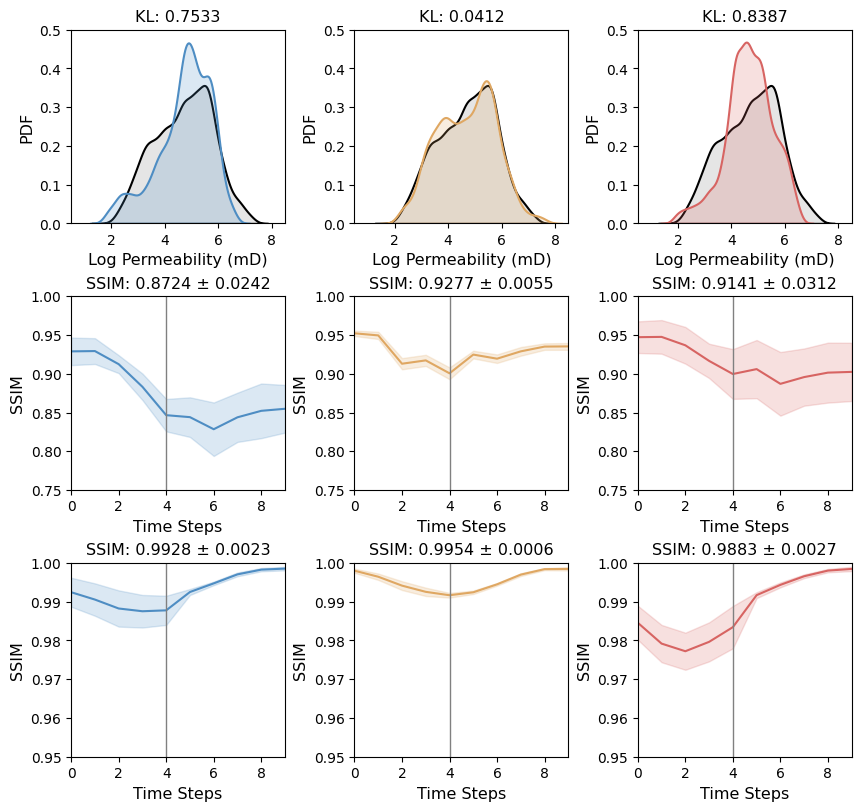

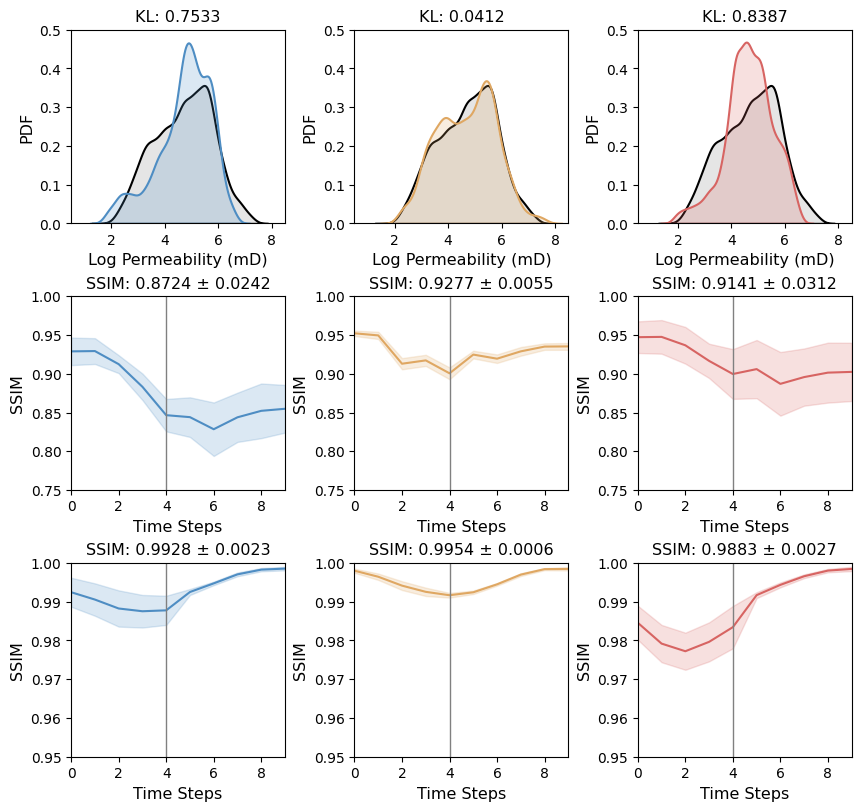

In [8]:
import numpy as np
from scipy.special import rel_entr  # elementwise p*log(p/q)
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.metrics import structural_similarity as ssim

def kl_ref_pred(field_ref, field_pred, bins=100, eps=1e-12, clip_percentile=(0.1, 99.9)):
    """
    估计 D_KL(P_ref || Q_pred)，用共享直方图估计两分布的边缘密度。
    - bins: 分箱数
    - eps: 频数平滑，避免 0
    - clip_percentile: 共享取值范围的稳健截断，减少尾部空箱
    - plot: 是否画对比直方图
    """
    x_ref = np.asarray(field_ref).ravel()
    x_pred = np.asarray(field_pred).ravel()

    lo = np.percentile(np.concatenate([x_ref, x_pred]), clip_percentile[0])
    hi = np.percentile(np.concatenate([x_ref, x_pred]), clip_percentile[1])

    p_hist, bin_edges = np.histogram(x_ref, bins=bins, range=(lo, hi), density=True)
    q_hist, _         = np.histogram(x_pred, bins=bin_edges, density=True)

    p = p_hist + eps
    q = q_hist + eps
    p /= p.sum()
    q /= q.sum()

    kl = float(np.sum(rel_entr(p, q)))

    return kl

def plot_hist(field_ref, field_pred, axs_toplot, color, fontsize):
    field_ref = np.asarray(field_ref).ravel()
    field_pred = np.asarray(field_pred).ravel()
    sns.kdeplot(x=field_ref, fill=True, ax=axs_toplot, color='black', alpha=0.1, linewidth=1.5,)
    sns.kdeplot(x=field_pred, fill=True, ax=axs_toplot, color=color, alpha=0.2, linewidth=1.5,)
    axs_toplot.set_title(f'KL: {kl_ref_pred(field_ref, field_pred):.4f}', fontsize=fontsize)
    axs_toplot.set_xlabel('Log Permeability (mD)', fontsize=fontsize)
    axs_toplot.set_ylabel('PDF', fontsize=fontsize)
    axs_toplot.set_xlim(0.5, 8.5)
    axs_toplot.set_ylim(0, 0.5)


def compute_temporal_ssim(field_ref, field_pred):
    ssim_values = []
    for i in range(field_pred.shape[0]):
        ssim_t_values = []
        for t in range(field_pred.shape[1]):
            ssim_value = ssim(field_ref[t, :, :], field_pred[i, t, :, :], data_range=field_ref[t, :, :].max() - field_ref[t, :, :].min())
            ssim_t_values.append(ssim_value)
        ssim_values.append(np.array(ssim_t_values))
    return np.array(ssim_values)  # shape (num_samples, time_steps)

def plot_ssim(field_ref, field_pred, axs_toplot, color, fontsize, y_bot=0.75):
    ssim_values = compute_temporal_ssim(field_ref, field_pred)
    mean_ssim = np.mean(ssim_values, axis=0)
    std_ssim = np.std(ssim_values, axis=0)
    x = np.arange(field_ref.shape[0])
    axs_toplot.plot(x, mean_ssim, color=color, linewidth=1.5)
    axs_toplot.fill_between(x, mean_ssim - std_ssim, mean_ssim + std_ssim, color=color, alpha=0.2)
    axs_toplot.set_title(f'SSIM: {mean_ssim.mean():.4f} ± {std_ssim.mean():.4f}', fontsize=fontsize)
    axs_toplot.set_ylim(y_bot, 1)
    axs_toplot.set_xlabel('Time Steps', fontsize=fontsize)
    axs_toplot.set_ylabel('SSIM', fontsize=fontsize)
    axs_toplot.axvline(x=4, color='gray', linewidth=1, ls='-')
    axs_toplot.set_xlim(0, field_ref.shape[0]-1)


cc_list = ['#4e8dc3', '#dfa762', '#d76462']
kk_list = [gene_3well_injection.mean(axis=0), gene_3well_injection_with_perm.mean(axis=0), gene_3well_injection_noise.mean(axis=0)]
ss_list = [ufno_sat_SAT, ufno_sat_SAT_with_perm, ufno_sat_SAT_noise]
pp_list = [ufno_pre_SAT, ufno_pre_SAT_with_perm, ufno_pre_SAT_noise]
print(kk_list[0].shape, ss_list[0].shape, pp_list[0].shape)


def plot_all(reference_k, reference_sat, reference_pre, k_genes, s_genes, p_genes, color_toplot):
    fig, axs = plt.subplots(3, 3, figsize=(8.5, 8), constrained_layout=True)
    axis_fontsize = 11.5
    
    for i in range(3):
        plot_hist(reference_k, k_genes[i], axs[0, i], color_toplot[i], axis_fontsize)
        plot_ssim(reference_sat, s_genes[i], axs[1, i], color_toplot[i], axis_fontsize)
        plot_ssim(reference_pre, p_genes[i], axs[2, i], color_toplot[i], axis_fontsize, y_bot=0.95)
    
    return fig


plot_all(ref_k, ref_sat, ref_pre, kk_list, ss_list, pp_list, cc_list)
# plt.savefig("conditional_outputs/figs_vertical_sp/overall_eva_3well.pdf", bbox_inches='tight')

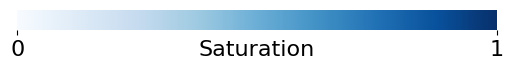

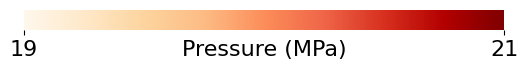

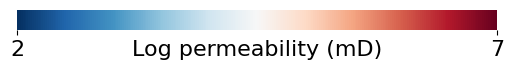

In [53]:
import matplotlib.colors as colors

def plot_colorbar(cmap_name, vmin, vmax, cbar_name, direction='horizontal'):
    cmap = plt.get_cmap(cmap_name)
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    
    if direction == 'horizontal':
        fig = plt.figure(figsize=(6, 2))
        cbar_ax = fig.add_axes([0.2, 0.5, 0.8, 0.1])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
        cbar.set_ticks([vmin, vmax])
        cbar.ax.set_xticklabels([str(vmin), str(vmax)])
        cbar.outline.set_visible(False)
        cbar.ax.tick_params(labelsize=16)
        cbar_ax.text(0.5, -1.0, f"{cbar_name}", transform=cbar_ax.transAxes,
                fontsize=16, ha='center', va='center')
        plt.savefig(f"conditional_outputs/figs_vertical_sp/colorbar_{cbar_name}.pdf", bbox_inches='tight')
    elif direction == 'vertical':
        fig = plt.figure(figsize=(2, 6))
        cbar_ax = fig.add_axes([0.5, 0.2, 0.1, 0.8])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
        cbar.set_ticks([vmin, vmax])
        cbar.ax.set_yticklabels([str(vmin), str(vmax)])
        cbar.outline.set_visible(False)
        cbar.ax.tick_params(labelsize=16)
        cbar_ax.text(2, 0.5, f"{cbar_name}", transform=cbar_ax.transAxes,
                fontsize=16, ha='center', va='center', rotation='vertical')
        plt.savefig(f"conditional_outputs/figs_vertical_sp/colorbar_{cbar_name}.pdf", bbox_inches='tight')

plot_colorbar('Blues', 0, 1, 'Saturation', 'horizontal')
plot_colorbar('OrRd', 19, 21, 'Pressure (MPa)', 'horizontal')
plot_colorbar('RdBu_r', 2, 7, 'Log permeability (mD)', 'horizontal')

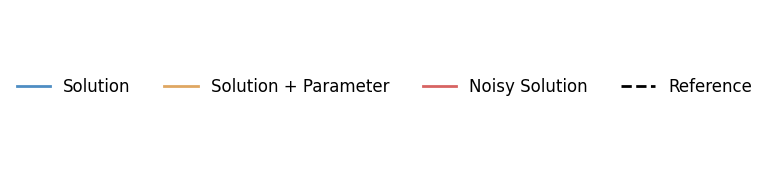

In [2]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 2))
custom_lines = [
    Line2D([0], [0], color='#4e8dc3', lw=2),
    Line2D([0], [0], color='#dfa762', lw=2),
    Line2D([0], [0], color='#d76462', lw=2),
    Line2D([0], [0], color='black', lw=2, ls='--'),
]
legend = ax.legend(custom_lines, ['Solution', 'Solution + Parameter', 'Noisy Solution', 'Reference'], 
                   loc='center', ncol=4, frameon=False, fontsize=12)
ax.axis('off')  # 不显示坐标轴
# plt.tight_layout()
plt.savefig('conditional_outputs/figs_vertical_sp/line_lengends.pdf', bbox_inches='tight')
plt.show()